<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency



### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv("novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`, "nivel_ingreso", "visitas_mes", "compras_mes", "gasto_publicidad_dirigida", "satisfaccion", 'ingreso_anual'
				

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna "edad" debe modificarse a INT para eliminar los decimales


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
df["edad"] = df["edad"].astype(int)

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
variables_numericas = [
    'edad',
    'nivel_ingreso', 
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'satisfaccion',
    'ingreso_anual'
]

df[variables_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — sin outliers aparentes, ni datos irreales como datos negativos, mismo caso para 'satisfaccion'
- `nivel_ingreso` - probables outliers dado que el max se ubica muy por encima del 3er cuartil, mismo caso para 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida' e 'ingreso_anual'

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
variables_binarias = [
    'miembro_premium',
    'abandono'
]
df[variables_binarias].value_counts()

miembro_premium  abandono
0                0           10741
                 1            2170
1                0            1998
                 1              91
dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — casi 13mil usarios No son miembro premium con un porcentaje de abandono del 15%, solo el 13% de usuarios son miembro premium
- `abandono` — el porcentaje de abandono entre los miembros tipo premium es muy bajo, solo el 4% contra el 15% de abandono que presenta el segmento no premium

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
variable_categorica = [
    'tipo_dispositivo',
    'region'
]

df[variable_categorica].nunique()

tipo_dispositivo    3
region              4
dtype: int64

In [9]:
# Explorar variables categóricas y cómo se distribuyen
df[variable_categorica].describe()


,tipo_dispositivo,region
count,15000,15000
unique,3,4
top,móvil,norte
freq,9818,4395


In [10]:


df[variable_categorica].value_counts()

tipo_dispositivo  region
móvil             norte     2843
                  oeste     2489
                  sur       2483
                  este      2003
escritorio        norte     1125
                  oeste      935
                  sur        894
                  este       766
tablet            norte      427
                  oeste      386
                  sur        349
                  este       300
dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — movil encabeza la categoria con 2 tercios de participacion en la categoria
- `region` — la region norte encabeza la categoria con 1 tercio de participacion en la categoria

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Los conjuntos datos se han revisado correctamente
</div>

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

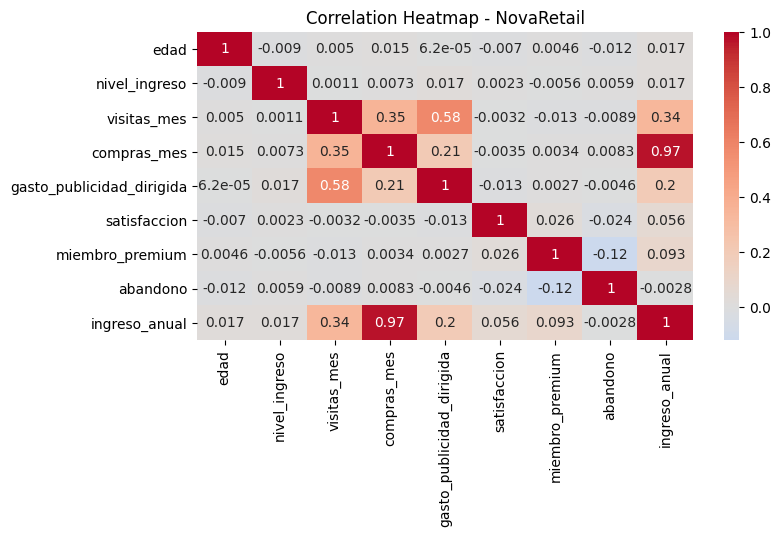

In [11]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr()

plt.figure(figsize=(8, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - NovaRetail")
plt.show()


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Gracias al mapa de calor podemos apreciar las correlaciones entre las columnas, algunas claramente no tienen alguna correlación mientras que hay otras que claramente influyen en los resultados, bien hecho!
</div>

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Relaciones débiles predominantes: La gran mayoría de las variables tienen correlaciones cercanas a cero (tanto positivas como negativas), lo que indica que casi todos los comportamientos y datos demográficos de los clientes se mueven de forma independiente entre sí.
- Bloque comercial fuertemente conectado: El único grupo de variables que muestra interacciones del mundo real realmente fuertes y significativas es el financiero/operativo, compuesto por ingreso_anual, compras_mes y visitas_mes.
- Aislamiento de la satisfacción y abandono: Las variables críticas de negocio como satisfaccion y abandono no tienen ninguna relación lineal con las variables económicas o demográficas, lo que significa que el descontento o la fuga de clientes ocurre por factores externos que este heatmap no está capturando.


Observaciones respecto a `ingreso_anual`  
- Relación casi perfecta (0.97): Existe una correlación positiva extremadamente fuerte con compras_mes. A mayor ingreso anual del cliente, aumenta de forma casi lineal y directa el volumen de transacciones mensuales. Por lo que se sospecha de posible colinealidad
- Relación moderada (0.34): Tiene un vínculo positivo moderado con visitas_mes. Los clientes con ingresos más altos tienden a registrar una mayor frecuencia de visitas a la tienda o plataforma.
- Relación débil (0.20): Muestra una correlación positiva baja con gasto_publicidad_dirigida. El presupuesto invertido en publicidad segmentada tiene un impacto muy leve en este segmento de ingresos.
- Vínculo nulo con fidelidad y retención: Las correlaciones con miembro_premium (0.093), satisfaccion (0.056) y abandono (-0.0028) son prácticamente cero. El nivel económico del cliente no influye en su decisión de abandonar la marca, en su felicidad con el servicio o en su estatus de suscripción.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

Saturación visual (Efecto "Pelo de Gato"): Al cruzar 9 variables, el gráfico generará una cuadrícula de 81 gráficos individuales en una sola pantalla. 
La mayoría de los puntos se verán encimados y será visualmente imposible detectar patrones, volviendo el gráfico inútil; ademas del Costo computacional innecesario que conlleva el grafico
Incompatibilidad de datos: El scatterplot solo funciona para relacionar dos variables numéricas continuas. En este dataset hay variables categóricas o binarias (como miembro_premium y abandono que solo son 0 o 1). Graficarlas así solo mostrará líneas paralelas sin sentido estadístico.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Excelente observación, no es necesario hacer tantas gráficas solo para observar cual nos conviene más
</div>

### Scatterplot para pares clave

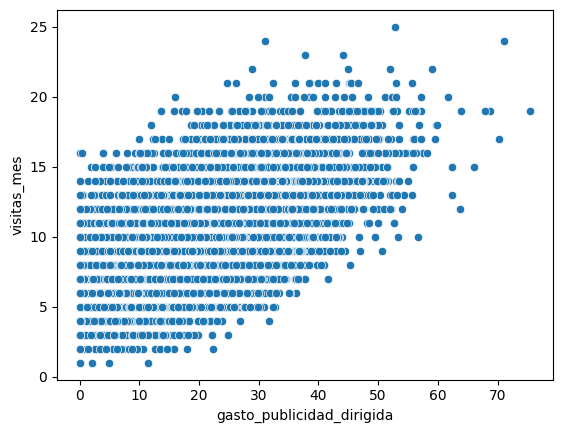

In [12]:
# Visualizar pares de variables con relaciones moderadas o fuertes



sns.scatterplot(data=df,x="gasto_publicidad_dirigida", y="visitas_mes")
plt.show()



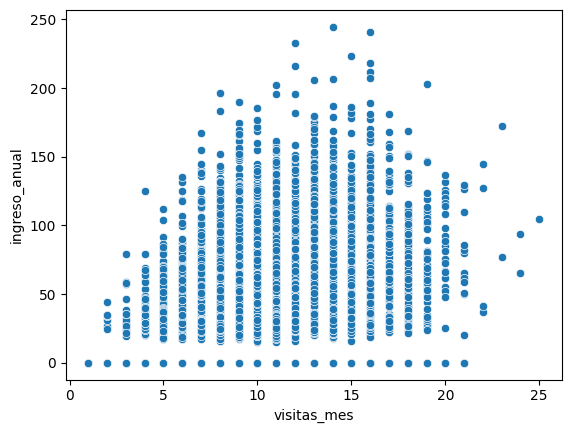

In [13]:

sns.scatterplot(data=df,x="visitas_mes", y="ingreso_anual")
plt.show()



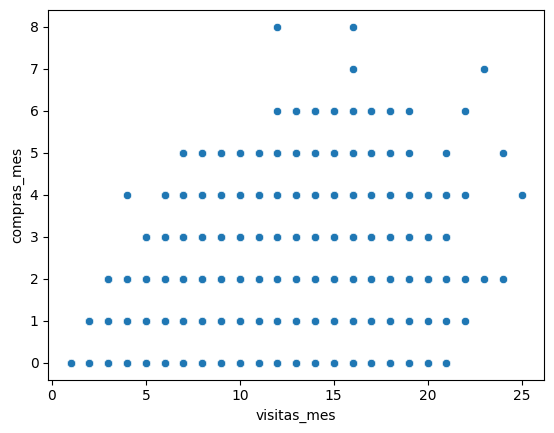

In [14]:
sns.scatterplot(data=df,x="visitas_mes", y="compras_mes")
plt.show()


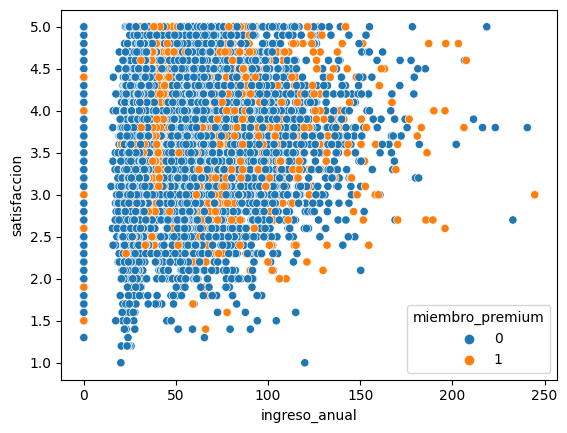

In [15]:
sns.scatterplot(data=df,x="ingreso_anual", y="satisfaccion", hue= 'miembro_premium')
plt.show()



<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Gracias a estas gráficas de disperción podemos observar claramente la correlación entre las columnas antes observadas
</div>

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**ingreso_anual vs compras_mes**
- Existe un riesgo extremadamente alto de colinealidad (y específicamente de multicolinealidad si utilizas más variables) entre ingreso_anual y compras_mes debido a su correlación de 0.97. Redundancia: Ambas variables están aportando exactamente la misma información predictiva al modelo.
  

**gasto_publicidad_dirigida vs visitas_mes**
- Dirección: Positiva. A medida que aumenta el gasto en publicidad, se observa una tendencia general al alza en las visitas mensuales.Dispersión: Alta. Los puntos forman una nube bastante ancha y extendida, lo que indica que el gasto publicitario no garantiza una cantidad exacta de visitas.Outliers (Valores atípicos): Baja o nula presencia. Hay puntos en los extremos (como el cliente con más de 70 en gasto o el de 25 visitas), pero siguen la forma de la distribución general sin aislarse por completo.Posible colinealidad: No existe riesgo. La dispersión es demasiado alta para sugerir dependencia lineal fuerte. Ambas variables pueden coexistir perfectamente en un modelo predictivo sin causar redundancia.
  

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [16]:
# Calcular correlación entre variables relevantes
pearson = df[variables_numericas].corr(method='pearson')
pearson

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
edad,1.000000,-0.009003,0.004998,0.014971,0.000062,-0.006963,0.017496
nivel_ingreso,-0.009003,1.000000,0.001060,0.007309,0.016834,0.002301,0.017446
visitas_mes,0.004998,0.001060,1.000000,0.353844,0.578947,-0.003179,0.337147
compras_mes,0.014971,0.007309,0.353844,1.000000,0.207528,-0.003542,0.967149
gasto_publicidad_dirigida,0.000062,0.016834,0.578947,0.207528,1.000000,-0.013175,0.197483
satisfaccion,-0.006963,0.002301,-0.003179,-0.003542,-0.013175,1.000000,0.056171
ingreso_anual,0.017496,0.017446,0.337147,0.967149,0.197483,0.056171,1.000000


In [17]:
# Calcular correlación entre variables relevantes
spearman = df[variables_numericas].corr(method='spearman')
spearman

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
edad,1.000000,-0.007775,0.005205,0.015630,0.002869,-0.007590,0.016097
nivel_ingreso,-0.007775,1.000000,0.001420,0.009004,0.015393,0.005243,0.025017
visitas_mes,0.005205,0.001420,1.000000,0.332943,0.559267,-0.001305,0.320954
compras_mes,0.015630,0.009004,0.332943,1.000000,0.192511,-0.002006,0.967482
gasto_publicidad_dirigida,0.002869,0.015393,0.559267,0.192511,1.000000,-0.012612,0.184999
satisfaccion,-0.007590,0.005243,-0.001305,-0.002006,-0.012612,1.000000,0.060834
ingreso_anual,0.016097,0.025017,0.320954,0.967482,0.184999,0.060834,1.000000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**gasto_publicidad_dirigida vs visitas_mes**
- Dirección: Positiva en ambos métodos (Pearson: 0.5789, Spearman: 0.5592). Esto ratifica matemáticamente que a mayor inversión en publicidad dirigida, el volumen de visitas mensuales tiende a incrementarse.Magnitud: Moderada-Alta. Un coeficiente de ~0.58 indica que existe una asociación lineal visible.
  

**visitas_mes vs compras_mes**
- Dirección: Positiva. Significa que los clientes que visitan la tienda o plataforma con mayor frecuencia también tienden a acumular un mayor número de compras al mes.Magnitud: Moderada-Baja. Un valor de ~0.35 revela que, aunque hay una tendencia positiva, la relación no es automática. Muchas visitas no se traducen directamente en transacciones; hay factores adicionales en juego (como la tasa de conversión o el interés del usuario).

### Punto-biserial

In [18]:
# Calcular correlación entre variables relevantes
for col in variables_numericas:
    coef, p_value = pointbiserialr(df["miembro_premium"],df[col])
    print(f"\nCorrelacion entre: miembro_premium y {col}")
    print(f"Point-Biserial: {coef:.4f}")

def corr_point_biserial(df, variables_binarias, variables_numericas):

        for col in columnas_numericas:
            coef, p_value = pointbiserialr(df["miembro_premium"],df[col])

            print(f"\nCorrelacion entre: miembro_premium y {col}")
            print(f"Point-Biserial: {coef:.4f}")



Correlacion entre: miembro_premium y edad
Point-Biserial: 0.0046

Correlacion entre: miembro_premium y nivel_ingreso
Point-Biserial: -0.0056

Correlacion entre: miembro_premium y visitas_mes
Point-Biserial: -0.0127

Correlacion entre: miembro_premium y compras_mes
Point-Biserial: 0.0034

Correlacion entre: miembro_premium y gasto_publicidad_dirigida
Point-Biserial: 0.0027

Correlacion entre: miembro_premium y satisfaccion
Point-Biserial: 0.0257

Correlacion entre: miembro_premium y ingreso_anual
Point-Biserial: 0.0931


In [19]:
for col in variables_numericas:
    coef, p_value = pointbiserialr(df["abandono"],df[col])
    print(f"\nCorrelacion entre: abandono y {col}")
    print(f"Point-Biserial: {coef:.4f}")

def corr_point_biserial(df, variables_binarias, variables_numericas):

        for col in columnas_numericas:
            coef, p_value = pointbiserialr(df["abandono"],df[col])

            print(f"\nCorrelacion entre: abandono y {col}")
            print(f"Point-Biserial: {coef:.4f}")


Correlacion entre: abandono y edad
Point-Biserial: -0.0115

Correlacion entre: abandono y nivel_ingreso
Point-Biserial: 0.0059

Correlacion entre: abandono y visitas_mes
Point-Biserial: -0.0089

Correlacion entre: abandono y compras_mes
Point-Biserial: 0.0083

Correlacion entre: abandono y gasto_publicidad_dirigida
Point-Biserial: -0.0046

Correlacion entre: abandono y satisfaccion
Point-Biserial: -0.0238

Correlacion entre: abandono y ingreso_anual
Point-Biserial: -0.0028


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**miembro_premium vs columnas numericas**
- Todas las variables analizadas muestran una magnitud extremadamente baja (casi nula). Esto significa que ninguna de estas variables numéricas tiene una relación lineal lineal importante con el hecho de ser o no un miembro premium.
- ingreso_anual (0.0931): Es la correlación más "alta" del grupo, pero sigue siendo muy baja. Indica una levísima tendencia a que las personas con mayor ingreso anual sean miembros premium.
- 
**abandono vs columnas numericas**
- Al igual que en el análisis anterior, todas las variables presentan una magnitud extremadamente baja o irrelevante (valores cercanos a 0). Ninguna variable numérica tiene una relación lineal fuerte o moderada con la probabilidad de abandono por sí sola.

### V de Cramér

In [20]:
# Función para calcular V de Cramér
def cramer_v(df, col1, col2):
    # tabla de contingencia
    tabla = pd.crosstab(df[col1], df[col2])
    
    # calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    
    # calcular coeficiente V de Cramér
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
    
    return v


In [21]:
# Aplicar V de Cramér en variables relevantes

cramer_v(df,"region","tipo_dispositivo")

0.012378338407739397

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Las coeficientes de correlación y asociación de la sección 4 fueron correctamente aplicados, bien hecho!
</div>

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér
]
- No existe una asociación relevante entre la región geográfica del usuario y el tipo de dispositivo que utiliza. Las dos variables se comportan de manera prácticamente independiente.El tipo de dispositivo preferido (por ejemplo: móvil, tablet, escritorio) se distribuye de manera muy similar en todas las regiones. No hay una región en particular que destaque por usar significativamente más un dispositivo que otra.
- 

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — 

**Evidencia visual:**  
Scatterplot de visitas_mes vs compras_mes

**Evidencia numérica:** 

Pearson (visitas_mes vs compras_mes) → correlación positiva moderada/alta.
Spearman (visitas_mes vs compras_mes) → asociación monotónica positiva consistente.

**Interpretación**  

Los clientes con mayor frecuencia de visitas tienden también a registrar un mayor volumen de compras mensuales. Esto sugiere una posible asociación entre nivel de interacción con la plataforma y actividad comercial.

**No podemos afirmar**  

No es posible concluir que aumentar visitas provoque directamente un incremento en compras, ya que podrían existir variables externas involucradas, como campañas comerciales, promociones o segmentación de clientes.


**Implicación de negocio**  

El patrón observado podría justificar hipótesis relacionadas con estrategias de engagement, navegación o retención orientadas a incrementar frecuencia de interacción de usuarios activos



### Hallazgo 2 — 

**Evidencia visual:**  

Scatterplot de satisfaccion vs ingreso_anual, utilizando miembro_premium como variable de color

**Evidencia numérica:** 

Punto-biserial (miembro_premium vs ingreso_anual) → correlación positiva moderada.

**Interpretación**  

Los clientes identificados como miembros premium muestran una tendencia a registrar mayores niveles de ingreso anual en comparación con clientes no premium.

**No podemos afirmar**  

No puede inferirse que la membresía premium genere mayores ingresos ni que clientes de mayores ingresos adopten necesariamente este tipo de membresía por causalidad directa.

**Implicación de negocio**  

El patrón podría apoyar hipótesis relacionadas con segmentación de clientes de alto valor, programas de fidelización y estrategias comerciales diferenciadas según perfil económico.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Las observaciones que haces me parecen bien explicadas, además estan en un formato correcto
</div>

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**

El análisis realizado es exclusivamente correlacional y exploratorio.
Las asociaciones identificadas no implican relaciones de causalidad.
Pueden existir variables no medidas que influyan en los patrones observados.
No se evaluaron efectos temporales ni cambios de comportamiento en el tiempo.
Algunas correlaciones podrían verse afectadas por outliers o distribuciones no normales.
Variables categóricas complejas podrían requerir codificación o segmentación adicional.
El análisis no contempla validación predictiva ni inferencia estadística avanzada.
Los resultados dependen de la calidad y representatividad del dataset disponible. 

### **Próximos pasos** 

Probar segmentación adicional

Segmentación por frecuencia de compra y nivel de interacción.
Segmentación por satisfacción, abandono y membresía premium.
Modelado predictivo
Construcción de modelos para estimar probabilidad de abandono de clientes.
Análisis experimental y temporal
Evaluar cambios de comportamiento a lo largo del tiempo mediante análisis longitudinal o pruebas A/B.

# Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, los procedimientos realizados son correctos, este es un ejercicio que nos ayuda a entender y comprobar que la correlación no siempre indica causalidad.<br/>    
<br/>    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
- El proyecto esta ordenado
- El proyecto es directo y conciso
- Se revisaron detalles muy minuciosamente con bastante cuidado
    
</div> 
